<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 11</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>



<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 11</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 10_01: Markov Prozesse** 
- Aufgabe 10_02: Integration mit MCMC 
- Aufgabe 10_03: Radom Walks 

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline"> Die Maus im Markov Labyrinth</td>


Wir wollen uns in dieser Aufgabe Markov Prozesse erster Ordnung anschauen. Markov Prozesse sind speziell in dem Sinne, dass die Zeitentwicklung der Zustände nur von einer begrenzten Anzahl vergangener Zustände abhängt. Bei Markov Prozessen erster Ordnung eben nur vom vorherigen Zustand.

Für einen Markov Prozess lässt sich ein Prozessdiagramm zeichnen, welches die Übergangswahrscheinlichkeiten zwischen den verschiedenen erlaubten Zuständen charakterisiert.

Hier einmal ein Beispiel:

<img src="transition_probs.png" width="500">

Zentrales Element weiterer Berechnungen ist die zugehörige Übergangsmatrix, welche für dieses Beispiel so definiert ist:

$$ W = \begin{pmatrix}
1/2 & 1/3 & 1/6 \\
3/4 & 0 & 1/4 \\
0 & 1 & 0
\end{pmatrix}$$

Es sollte aufgefallen sein, dass die Summe der Zeilen immer 1 ergibt.
Ein Zustand ist ein liegender Vektor, welcher die momentanen Wahrscheinlichkeiten jedes Zustandes beinhaltet.

$$ \vec{\pi} = (1/2, 1/2, 0)$$

Die Summe der einzelnen Wahrscheinlichkeiten der Zustände müssen auch immer 1 ergeben, um einen güligen Zustand zu generieren.

Von extremer Wichtigkeit sind stabile Zustände, also solche Zustände, die folgende Eigenwertgleichung lösen:

$$ \vec{\pi} \cdot W = \vec{\pi}$$

Der stabile Zustand dieser Beispielmatrix ist:

$$ \vec{\pi_S} = (1/2, 1/3, 1/6)$$

## Nun zur eigentlichen Aufgabe:

Eine Maus bewegt sich durch das Markov Labyrinth. Dabei kann sie mit jedem Schritt in jeden angrenzenden Raum wechseln, bleibt aber niemals im selben Raum. Die Wechselwahrscheinlichkeit hängt dabei ausschließlich von der Anzahl der angrenzenden Räume ab.

Die Räume sind wie folgt verteilt:


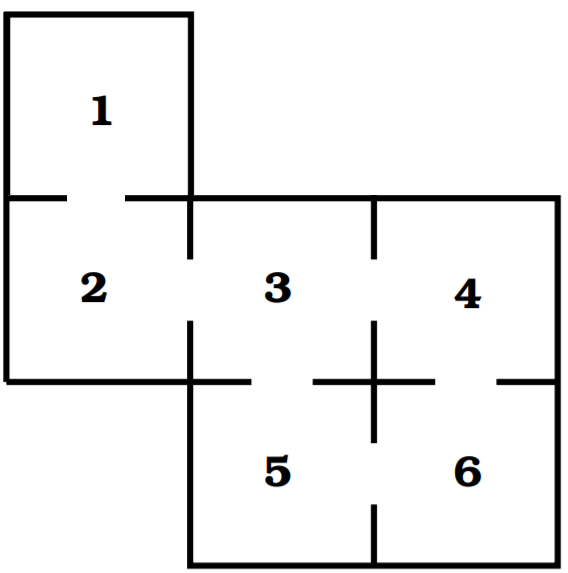

### a) Definieren des Systems
Zeichnen Sie das zugehörige Prozessdiagramm und bestimmen Sie die Übergangsmatrix für diesen Prozess.
Speichern Sie die Matrix direkt als Variable ab.

In [1]:
using LinearAlgebra
using Plots

In [3]:
W = [0     1     0     0     0     0;
     1/2   0     1/2   0     0     0;
     0     1/3   0     1/3   1/3   0;
     0     0     1/2   0     0     1/2;
     0     0     1/2   0     0     1/2;
     0     0     0     1/2   1/2   0]

# Kontrolle: jede Zeile muss sich zu 1 aufsummieren (Wahrscheinlichkeit)
println("Zeilensummen von W: ", sum(W, dims=2))

Zeilensummen von W: [1.0; 1.0; 1.0; 1.0; 1.0; 1.0;;]


### b) Bestimmung des stabilen Zustandes 1 

Die Eigenwertgleichung zur Bestimmung des stabilen Zustandes ist in dieser Form nicht so einfach für Julia zu lösen.
Mit einigen wenigen Umformungen lässt sich diese Gleichung allerdings wieder in die Form $W' \vec{\pi_S}^T = \vec{0}$ bringen, wobei $W'$ von $W$ abhängt und $\vec{\pi_S}$ der stabile Zustand ist.

Bestimmen Sie $W'$.

#### Hinweis: $$ (A * B)^T = B^T * A^T$$

Wenn Sie diese Gleichung nun mit Julia lösen lassen, wird immer die triviale Lösung $\vec{\pi_S} = \vec{0}$ heraus kommen.
Dies ist aber nicht einmal ein erlaubter Zustand. Welche zusätzliche Bedingung muss gelten, um einen erlaubten Zustand zu generieren?

**Herleitung von $W'$:**

Aus $\vec{\pi} \cdot W = \vec{\pi}$ folgt $\vec{\pi} \cdot W - \vec{\pi} \cdot I = \vec{0}$, also $\vec{\pi}\,(W - I) = \vec{0}$.

Transponiert man diese Gleichung (mit dem Hinweis $(A\,B)^T = B^T A^T$), erhält man:
$$(W-I)^T \vec{\pi}^T = \vec{0} \quad\Longleftrightarrow\quad (W^T - I)\,\vec{\pi}^T = \vec{0}$$

Also ist $W' = W^T - I$.

**Zusätzliche Bedingung:** Das homogene Gleichungssystem $W' \vec{\pi_S}^T = \vec{0}$ hat immer die triviale Lösung $\vec{\pi_S} = \vec{0}$, da $W'$ singulär ist (Nullraum mindestens eindimensional). Um den *erlaubten*, nichttrivialen stabilen Zustand zu erhalten, muss zusätzlich die **Normierungsbedingung**
$$\sum_i (\pi_S)_i = 1$$
gelten. Praktisch ersetzt man dazu eine Zeile des (singulären) Gleichungssystems durch diese Normierungsbedingung, um ein eindeutig lösbares System zu erhalten (siehe Teilaufgabe c).

In [6]:
# W' = W^T - I
Wp = transpose(W) - I


display(Wp)

6×6 Matrix{Float64}:
 -1.0   0.5   0.0        0.0   0.0   0.0
  1.0  -1.0   0.333333   0.0   0.0   0.0
  0.0   0.5  -1.0        0.5   0.5   0.0
  0.0   0.0   0.333333  -1.0   0.0   0.5
  0.0   0.0   0.333333   0.0  -1.0   0.5
  0.0   0.0   0.0        0.5   0.5  -1.0

In den folgenden Aufgaben werden verschiedene Ansätze verwendet um normierte stabile Zustände zu generieren!

### c) Bestimmung des stabilen Zustandes 2 

Schreiben Sie nun eine Funktion, welche mit Hilfe des linearen Gleichungssystems, welches sie in b) gefunden haben den stabilen Zustand einer beliebigen Übergangsmatrix berechnet. 

Tip: Können die (Normierungs-)Bedingung direkt in das lineare Gleichungssystem einpflegen? 

Überprüfen Sie mit Hilfe des Beispielprozesses ob Ihre Funktion korrekte Ergebnisse liefert und bestimmen Sie im Anschluss den stabilen Zustand des Markov Labyrinths.

In [7]:
function stable_state(W)
    d = size(W, 1)
    # Aufstellen des (noch singulären) Gleichungssystems W' * pi^T = 0
    A = transpose(W) - I(d)

    # Normierungsbedingung sum(pi) = 1 einbauen, indem wir eine Zeile
    # (hier die letzte) durch die Normierungs-Gleichung ersetzen.
    A[end, :] .= 1
    b = zeros(d)
    b[end] = 1

    pi_s = A \ b
    return pi_s
end

# Test mit dem Beispielprozess aus der Angabe (sollte (1/2, 1/3, 1/6) liefern):
W_test = [1/2  1/3  1/6;
          3/4  0    1/4;
          0    1    0]
println("Test am Beispielprozess: ", stable_state(W_test))

# Stabiler Zustand des Mäuse-Labyrinths:
pi_maze = stable_state(W)
println("Stabiler Zustand des Labyrinths: ", pi_maze)

Test am Beispielprozess: [0.5, 0.3333333333333333, 0.16666666666666666]
Stabiler Zustand des Labyrinths: [0.08333333333333327, 0.16666666666666655, 0.25, 0.16666666666666669, 0.16666666666666669, 0.16666666666666669]


### d) Bestimmung des stabilen Zustandes 3

Eine Möglichkeit den stabilen Zustand zu bestimmen, ist durch wiederholtes Anwenden der Übergangsmatrix auf den Zustand.

Erstellen Sie dafür zunächst eine Funktion rand_state(d) welche einen zufälligen erlaubten Zustand im d-Dimensionalen Zustandsraum erzeugt.

Wenden Sie anschließend die Übergangsmatrix bis zu 20 Mal auf einen solchen Zustand an und messen Sie jedes Mal den Fehler $sum((xW-x)^2)$.


**Nach wie vielen Iterationen kovergiert das System, wenn überhaupt? Zu welchen Zustand konvergiert es? Warum? (Tip: Eigenzerlegung könnte nützlich sein.) Gibt es nur einen steady state?**

**Antwort (nach Durchführung der Iteration unten):**

Die Eigenwerte von $W$ sind (numerisch) ungefähr:
$$1,\quad 0.707,\quad 0,\quad 0,\quad -0.707,\quad -1$$

Es gibt also neben dem erwarteten Eigenwert $\lambda=1$ (zugehörig zum stabilen Zustand $\vec{\pi_S}$) auch einen Eigenwert $\lambda=-1$! Das liegt daran, dass der Nachbarschaftsgraph des Labyrinths **bipartit** ist: Die Räume lassen sich in zwei Gruppen $\{1,3,6\}$ und $\{2,4,5\}$ einteilen, zwischen denen die Maus bei *jedem* Schritt wechselt (nie innerhalb einer Gruppe).

Deshalb konvergiert die naive Iteration $\vec{\pi}_{n+1} = \vec{\pi}_n W$ im Allgemeinen **nicht** gegen einen festen Punkt — der Fehler oszilliert periodisch (Periode 2), statt gegen 0 zu gehen, außer man startet zufällig exakt im stabilen Zustand. Nur der Mittelwert zweier aufeinanderfolgender Iterationen (bzw. die Anwendung von $W^2$) konvergiert wirklich.

Da der Eigenwert $\lambda=1$ trotzdem nur einfach auftritt (algebraische Vielfachheit 1) und der Graph zusammenhängend (irreduzibel) ist, gibt es dennoch **nur einen** stabilen/stationären Zustand $\vec{\pi_S}$ — er ist eindeutig, auch wenn die einfache Iteration nicht monoton dorthin konvergiert.

6-element Vector{Float64}:
 0.07419470437090368
 0.1846541180294991
 0.2228428212812256
 0.18483011970402471
 0.18483011970402471
 0.14864811691032193

Fehler pro Iteration: [0.05269843670104542, 0.010801391958570161, 0.00879002139904345, 0.009236257358260749, 0.00846150238814498, 0.0087729058997159, 0.008443260992069917, 0.00862103413084594, 0.008470644821375923, 0.008565049236511585, 0.008493462867864824, 0.008542044536869563, 0.008507153424068244, 0.008531789123929844, 0.008514569085409695, 0.008526973151680297, 0.008518419511890349, 0.008524643099110602, 0.008520380374083165, 0.008523497556214532]


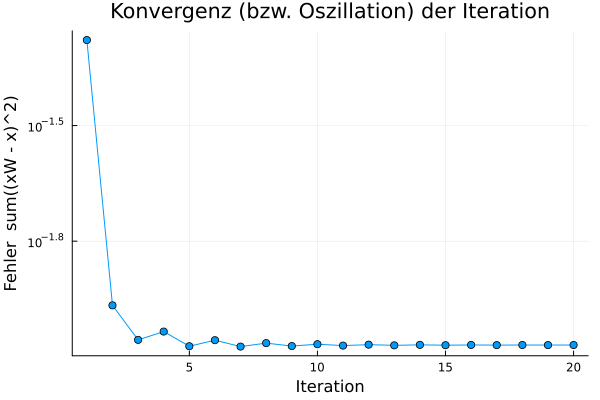

In [24]:
function rand_state(d)
    x = rand(d)
    return x ./ sum(x)     # normieren, damit sum(x) == 1 (gültiger Zustand)
end

x = rand_state(6)
errors = Float64[]

for n in 1:20
    x_new = transpose(W) * x     # entspricht pi_neu = pi * W (hier als Spaltenvektor geschrieben)
    err = sum((x_new .- x).^2)
    push!(errors, err)
    global x = x_new
end
display(x)
println("Fehler pro Iteration: ", errors)

plot(1:20, errors,
     xlabel="Iteration", ylabel="Fehler  sum((xW - x)^2)",
     yscale=:log10, marker=:circle, legend=false,
     title="Konvergenz (bzw. Oszillation) der Iteration")

### e) Statitische simulation

Anstatt deterministisch im Limes der großen Zahlen zu arbeiten, sollen Sie jetzt eine Statistische Simulation schreiben.
Wir starten mit 100 Mäusen im ersten Raum.
Sie können mit der Funktion `Multinomial` von der Übergangswahrscheinlichkeit in die nächsten Räume samplen (Siehe Beispiel).

Tun Sie das für $N=1000$ schritte mit den 100 Mäusen. Vergleichen sie ihr Ergebniss mit der stationären Verteilung die sie in d) durch vielmaliges anwenden der Übergangsmatrix erhalten haben.

In [25]:
using Distributions
probs = [0.3, 0.3, 0.2, 0.15, 0.05, 0]
mnd = Multinomial(100, probs)
rand(mnd)

6-element Vector{Int64}:
 20
 31
 19
 19
 11
  0

In [26]:
N_mice = 100
N_steps = 1000

# Startzustand: alle Mäuse in Raum 1
counts = zeros(Int, 6)
counts[1] = N_mice

for step in 1:N_steps
    new_counts = zeros(Int, 6)
    for room in 1:6
        if counts[room] > 0
            # Für jeden belegten Raum: Mäuse gemäß der Übergangswahrscheinlichkeiten
            # in W[room, :] auf die Nachbarräume verteilen (Multinomial-Sampling)
            mnd = Multinomial(counts[room], W[room, :])
            new_counts .+= rand(mnd)
        end
    end
    global counts = new_counts
end

verteilung_sim = counts ./ N_mice
println("Simulierte Verteilung nach $N_steps Schritten: ", verteilung_sim)
println("Stationäre Verteilung aus Teil d): ", pi_maze)
println("Differenz: ", verteilung_sim .- pi_maze)

Simulierte Verteilung nach 1000 Schritten: [0.18, 0.0, 0.49, 0.0, 0.0, 0.33]
Stationäre Verteilung aus Teil d): [0.08333333333333327, 0.16666666666666655, 0.25, 0.16666666666666669, 0.16666666666666669, 0.16666666666666669]
Differenz: [0.09666666666666672, -0.16666666666666655, 0.24, -0.16666666666666669, -0.16666666666666669, 0.16333333333333333]


**Wichtige Beobachtung:** Da der Nachbarschaftsgraph bipartit ist (siehe Teil d), befinden sich nach einer **geraden** Anzahl Schritte alle Mäuse zwangsläufig in Räumen $\{1,3,6\}$, nach einer **ungeraden** Anzahl Schritte in $\{2,4,5\}$ (wenn man in Raum 1 startet). Bei $N=1000$ Schritten (gerade) ist die simulierte Verteilung in den Räumen 2, 4, 5 daher exakt 0 — sie weicht dadurch systematisch von der stationären Verteilung $\vec\pi_S$ ab, die ja Wahrscheinlichkeit auf *alle* Räume verteilt. Das ist keine statistische Ungenauigkeit, sondern eine direkte Konsequenz der Periodizität aus Teil d). Erst ein zeitliches **Mittel** über mehrere (aufeinanderfolgende, gerade *und* ungerade) Schritte nähert sich $\vec\pi_S$ an.